# External Quantum Efficiency (EQE) of Solar Cells

A solar cell turns photons into current. How well it does that depends
strongly on the **wavelength** of the light. Quantum efficiency
measurements resolve the conversion process wavelength by wavelength, and
are the standard way to find out *where* in a cell the losses happen.

This notebook builds the technique up from first principles:

| Section | Question answered |
|---|---|
| 1-2 | How deep does light of a given wavelength go? |
| 3 | Where do the incident photons end up? |
| 4 | Which generated carriers survive to be collected? |
| 5 | What is EQE, and what shapes its curve? |
| 6 | What is IQE, and why separate it from EQE? |
| 7 | What is spectral response, and why is it what we measure? |
| 8 | How do we get $J_{sc}$ back out of an EQE curve? |
| 9 | What do EQE and IQE reveal about a real device? |
| 10-12 | How is the measurement actually performed and calibrated? |

<div align="center">
   <img src="./figures/fig_cell_structure.jpg" width="620">
</div>

Equations are numbered (1), (2), ... and referred to by those numbers
throughout. All physics functions live in
[`eqe_helper.py`](./eqe_helper.py), so the notebook itself stays short;
that module's docstrings point back to these equation numbers.

In [1]:
# --- Google Colab setup -------------------------------------------------
# Colab opens this notebook file on its own, without the rest of the
# repository, so eqe_helper.py and figures/ would be missing. This cell
# clones the repo and switches into the EQE folder when (and only when)
# running on Colab. It does nothing when you run the notebook locally.
import os
import sys
import subprocess

if "google.colab" in sys.modules and not os.path.exists("eqe_helper.py"):
    REPO_URL = "https://github.com/YOUR_GH_USERNAME/semicon_characterisation.git"
    subprocess.run(["git", "clone", "-q", REPO_URL, "/content/semicon"], check=True)
    os.chdir("/content/semicon/EQE")
    print("Colab setup complete, working directory:", os.getcwd())

## 1. Photons and the useful wavelength range

The energy carried by one photon is

$$
E_{\text{phot}}(\lambda) = \frac{hc}{\lambda} \tag{1}
$$

with $h$ the Planck constant and $c$ the speed of light. Short wavelength
= high energy.

To generate an electron-hole pair, a photon needs at least the bandgap
energy $E_g$. For silicon $E_g = 1.12\ \text{eV}$, which by (1)
corresponds to $\lambda \approx 1107\ \text{nm}$ — the **absorption
edge**. Longer wavelengths pass through without generating carriers, so
the useful range for a silicon cell is roughly 300-1200 nm.

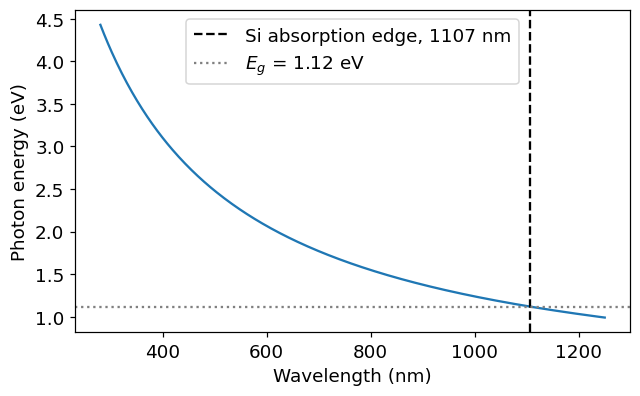

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import eqe_helper as eh

plt.rcParams.update({'font.size': 12})

wavelength_nm = np.linspace(280, 1250, 400)
E_photon = eh.photon_energy_eV(wavelength_nm)      # Eq. (1)

plt.figure(figsize=(6, 3.8))
plt.plot(wavelength_nm, E_photon)
plt.axvline(eh.LAMBDA_G_NM, ls='--', color='k',
            label=f'Si absorption edge, {eh.LAMBDA_G_NM:.0f} nm')
plt.axhline(eh.EG_SI_EV, ls=':', color='gray', label='$E_g$ = 1.12 eV')
plt.xlabel('Wavelength (nm)'); plt.ylabel('Photon energy (eV)')
plt.legend(); plt.tight_layout(); plt.show()

## 2. Absorption: how deep does the light go?

Inside the semiconductor, the photon flux decays exponentially with depth
$z$ (Lambert-Beer):

$$
\Phi(\lambda, z) = \Phi_0(\lambda)\, e^{-\alpha(\lambda)\, z} \tag{2}
$$

where $\alpha(\lambda)$ is the **absorption coefficient**. The depth at
which the flux has fallen to $1/e \approx 37\%$ is the **absorption
length**:

$$
L_\alpha(\lambda) = \frac{1}{\alpha(\lambda)} \tag{3}
$$

Silicon has an *indirect* bandgap: absorption near $E_g$ needs phonon
assistance, so $\alpha$ decreases gradually over hundreds of nm rather
than cutting off sharply. Across 300-1200 nm it varies by **six orders of
magnitude** — the single most important fact behind the shape of an EQE
curve.

  300 nm : L_alpha =      0.010 um
  500 nm : L_alpha =      1.000 um
  800 nm : L_alpha =     25.000 um
 1000 nm : L_alpha =    294.118 um
 1100 nm : L_alpha =   1666.667 um


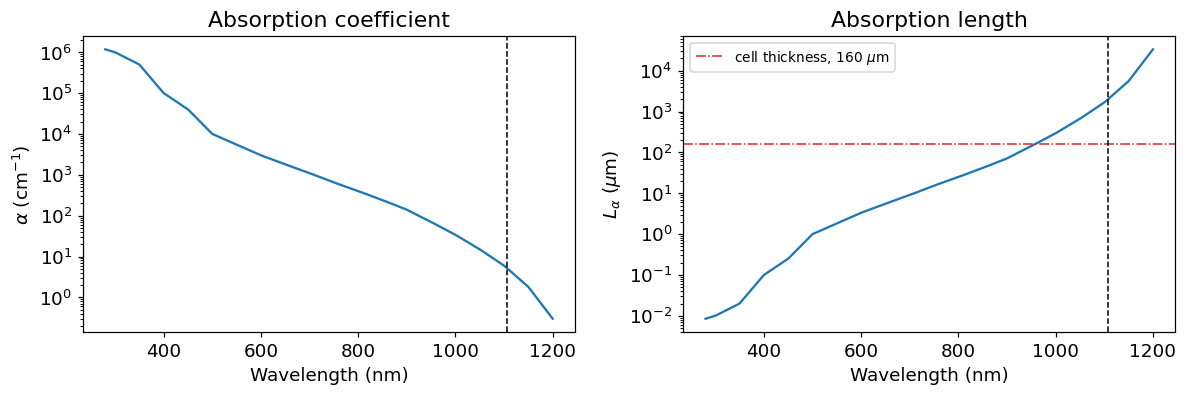

In [3]:
wl = np.linspace(280, 1200, 400)
alpha = eh.alpha_silicon(wl)             # 1/cm
L_alpha = eh.absorption_length_um(wl)    # um, Eq. (3)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].semilogy(wl, alpha)
axes[0].axvline(eh.LAMBDA_G_NM, ls='--', color='k', lw=1)
axes[0].set_xlabel('Wavelength (nm)')
axes[0].set_ylabel(r'$\alpha$ (cm$^{-1}$)')
axes[0].set_title('Absorption coefficient')

axes[1].semilogy(wl, L_alpha)
axes[1].axhline(160, ls='-.', color='C3', lw=1, label='cell thickness, 160 $\\mu$m')
axes[1].axvline(eh.LAMBDA_G_NM, ls='--', color='k', lw=1)
axes[1].set_xlabel('Wavelength (nm)')
axes[1].set_ylabel(r'$L_\alpha$ ($\mu$m)')
axes[1].set_title('Absorption length')
axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()

for wl_i in [300, 500, 800, 1000, 1100]:
    print(f"{wl_i:5d} nm : L_alpha = {eh.absorption_length_um(wl_i):10.3f} um")

Read the right-hand plot against the cell thickness line:

- **300 nm**: $L_\alpha \approx 0.01\ \mu\text{m}$. All the light is
  absorbed in the first few tens of nm — inside the coating and emitter,
  right at the front surface.
- **800 nm**: $L_\alpha \approx 25\ \mu\text{m}$. Absorbed comfortably
  inside the base, well away from both surfaces. This is the cell's
  sweet spot.
- **1100 nm**: $L_\alpha \gg W$. Most light crosses the whole cell and
  reaches the rear, where it may escape or be reflected back.

So **wavelength selects depth**, and depth decides which loss mechanism
the carriers will meet. That is what makes a wavelength-resolved
measurement so diagnostic.

## 3. Where do the incident photons go?

Before any carrier physics, some photons never reach the absorber at all.
Of the light arriving at the cell, a fraction $R$ is **reflected**, and a
fraction $A_{\text{ext}}$ is **parasitically absorbed** in layers that
generate no usable current (the anti-reflection coating, the metal
fingers, the heavily doped emitter). What is left is transmitted into the
absorber — the **external transmission**:

$$
T_{\text{ext}}(\lambda) = 1 - R(\lambda) - A_{\text{ext}}(\lambda) \tag{4}
$$

<div align="center">
   <img src="./figures/fig_optical_losses.jpg" width="640">
</div>

This split is the reason two different efficiencies are needed. One
counts carriers per *incident* photon (EQE, Section 5); the other counts
carriers per photon that *got in* (IQE, Section 6). Keeping them apart is
what lets you tell an optical problem from an electrical one.

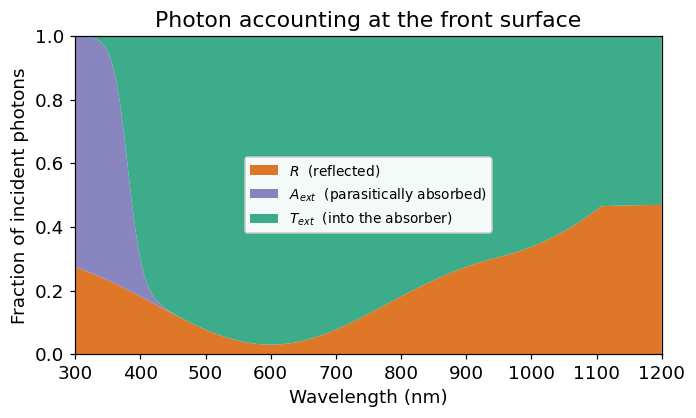

In [4]:
wl = np.linspace(300, 1200, 300)

R = eh.arc_reflectance(wl)                  # front-surface reflectance
T_ext = eh.external_transmission(wl)        # Eq. (4)
A_ext = 1 - R - T_ext                       # parasitic absorption

plt.figure(figsize=(6.5, 4))
plt.stackplot(wl, R, A_ext, T_ext,
              labels=['$R$  (reflected)',
                      '$A_{ext}$  (parasitically absorbed)',
                      '$T_{ext}$  (into the absorber)'],
              colors=['#d95f02', '#7570b3', '#1b9e77'], alpha=0.85)
plt.xlabel('Wavelength (nm)'); plt.ylabel('Fraction of incident photons')
plt.ylim(0, 1); plt.xlim(wl.min(), wl.max())
plt.legend(loc='center', fontsize=9, framealpha=0.95)
plt.title('Photon accounting at the front surface')
plt.tight_layout(); plt.show()

The anti-reflection coating works best near its design wavelength
(~600 nm here), where almost everything gets in. In the UV, parasitic
absorption dominates. At long wavelengths reflection rises again, because
weakly absorbed light reaches the rear surface and can leave the cell.

## 4. Generation and collection

Every absorbed photon generates one electron-hole pair. The generation
rate per unit depth follows by differentiating (2):

$$
g(\lambda, z) = -\frac{d\Phi}{dz}
= \big(1-R(\lambda)\big)\,\Phi_0(\lambda)\,\alpha(\lambda)\, e^{-\alpha(\lambda) z} \tag{5}
$$

Generating a carrier is not enough — it must reach a contact before it
recombines. A minority carrier with diffusion constant $D$ and lifetime
$\tau$ travels, on average, a **diffusion length**

$$
L = \sqrt{D\tau} \tag{6}
$$

before recombining. The probability that a carrier generated at depth $z$
is actually collected is the **collection efficiency**:

$$
\eta_c(z) = \cosh\!\left(\frac{z}{L}\right)
          - \frac{L}{L_{\text{eff}}}\,\sinh\!\left(\frac{z}{L}\right) \tag{7}
$$

$$
L_{\text{eff}} = L\,
\frac{S\sinh(W/L) + D\cosh(W/L)}{S\cosh(W/L) + D\sinh(W/L)} \tag{8}
$$

where $W$ is the base thickness and $S$ the **rear surface recombination
velocity**. Two knobs matter: a longer $L$ (better bulk material) and a
smaller $S$ (better rear passivation) both raise $\eta_c$ deep in the
cell.

<div align="center">
   <img src="./figures/fig_collection_efficiency.jpg" width="620">
</div>

L = sqrt(D*tau) for D=27 cm^2/s, tau=100 us : 520 um   [Eq. (6)]


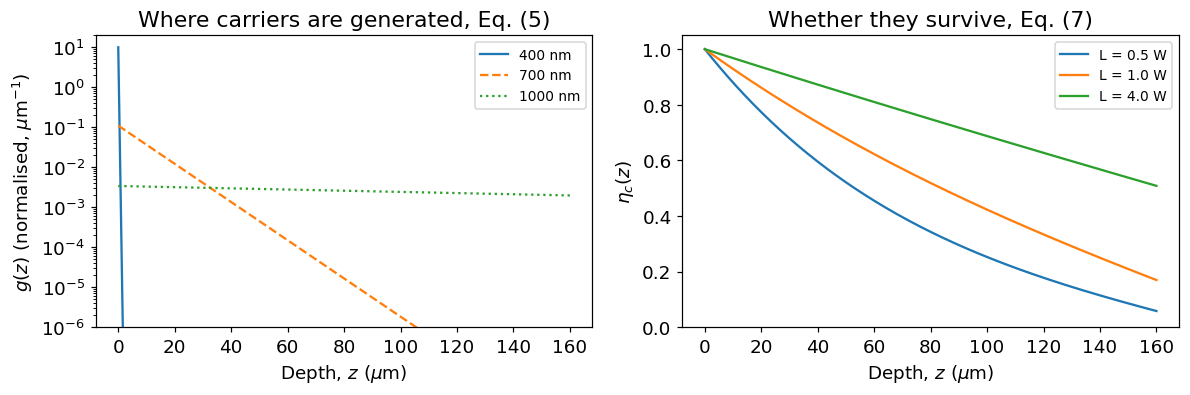

In [5]:
z = np.linspace(0, 160, 400)   # depth, um
W = 160.0                       # base thickness, um

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

# Generation profiles, Eq. (5) - log scale, decay lengths span decades
for wl_i, style in zip([400, 700, 1000], ['-', '--', ':']):
    axes[0].semilogy(z, eh.generation_profile(z, wl_i), style, label=f'{wl_i} nm')
axes[0].set_xlabel(r'Depth, $z$ ($\mu$m)')
axes[0].set_ylabel(r'$g(z)$ (normalised, $\mu$m$^{-1}$)')
axes[0].set_title('Where carriers are generated, Eq. (5)')
axes[0].set_ylim(1e-6, 20); axes[0].legend(fontsize=9)

# Collection efficiency, Eq. (7), for different diffusion lengths
for L_i in [0.5 * W, 1.0 * W, 4.0 * W]:
    axes[1].plot(z, eh.collection_efficiency(z, L_um=L_i, W_um=W, S_cm_s=100.0),
                 label=f'L = {L_i / W:.1f} W')
axes[1].set_xlabel(r'Depth, $z$ ($\mu$m)')
axes[1].set_ylabel(r'$\eta_c(z)$')
axes[1].set_title('Whether they survive, Eq. (7)')
axes[1].set_ylim(0, 1.05); axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()

print(f"L = sqrt(D*tau) for D=27 cm^2/s, tau=100 us : "
      f"{eh.diffusion_length_um(27.0, 100.0):.0f} um   [Eq. (6)]")

Put the two panels together and the whole technique follows: blue
light generates carriers where $\eta_c$ is high but the front losses are
worst; red light generates them deep, where $\eta_c$ has decayed.

## 5. External quantum efficiency

**EQE is the fraction of incident photons that produce a collected
electron.** Weighting the generation profile (5) by the collection
efficiency (7) and integrating over the cell thickness:

$$
\text{EQE}(\lambda) = \frac{1}{\Phi_0(\lambda)}\int_0^{W} g(\lambda,z)\,\eta_c(z)\, dz \tag{9}
$$

EQE is dimensionless and lies between 0 and 1. It is "external" because
it is referenced to the photons arriving at the cell — reflection losses
included, and therefore counted against the cell.

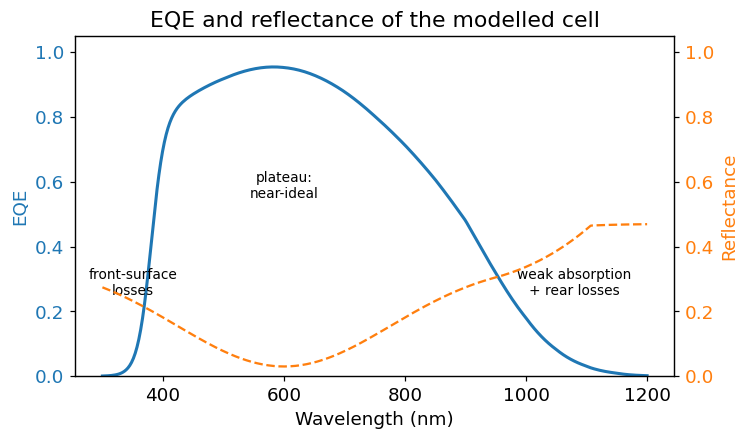

In [6]:
wl = np.linspace(300, 1200, 300)

eqe = eh.eqe_spectrum(wl, W_um=160.0, L_um=250.0, S_cm_s=100.0)   # Eq. (9)
R = eh.arc_reflectance(wl)

fig, ax1 = plt.subplots(figsize=(7, 4.2))
ax1.plot(wl, eqe, color='C0', lw=2, label='EQE')
ax1.set_xlabel('Wavelength (nm)'); ax1.set_ylabel('EQE', color='C0')
ax1.set_ylim(0, 1.05); ax1.tick_params(axis='y', labelcolor='C0')

ax2 = ax1.twinx()
ax2.plot(wl, R, color='C1', ls='--', label='Reflectance $R$')
ax2.set_ylabel('Reflectance', color='C1')
ax2.set_ylim(0, 1.05); ax2.tick_params(axis='y', labelcolor='C1')

ax1.annotate('front-surface\nlosses', xy=(350, 0.25), fontsize=9, ha='center')
ax1.annotate('plateau:\nnear-ideal', xy=(600, 0.55), fontsize=9, ha='center')
ax1.annotate('weak absorption\n+ rear losses', xy=(1080, 0.25), fontsize=9, ha='center')

plt.title('EQE and reflectance of the modelled cell')
fig.tight_layout(); plt.show()

The three regions of every silicon EQE curve:

- **UV / blue (300-450 nm)**: light is absorbed in the coating and
  emitter. Parasitic absorption and heavy front recombination make EQE
  low. This region reports on **front surface quality**.
- **Plateau (450-900 nm)**: light enters easily (ARC minimum) and is
  absorbed in the base, where collection is efficient. EQE approaches its
  maximum. The gentle slope tracks the rise in $R$.
- **Near-IR (>950 nm)**: $\alpha$ collapses, so light is absorbed deep,
  weakly, or not at all. This region reports on **bulk lifetime and rear
  surface**.

## 6. Internal quantum efficiency

EQE mixes two very different things: how much light *gets into* the cell
(optics) and how well the carriers it makes are *collected*
(electronics). A cell can have poor EQE simply because its coating
reflects badly — with nothing wrong electrically.

**IQE removes the optical loss.** It counts collected electrons per
photon that actually entered the cell:

$$
\text{IQE}(\lambda) = \frac{\text{EQE}(\lambda)}{1 - R(\lambda)} \tag{10}
$$

This is the form used in practice, because $R(\lambda)$ is measured with
a spectrophotometer alongside the EQE. Accounting for parasitic
absorption as well, using $T_{\text{ext}}$ from (4), gives the more
complete statement:

$$
\text{EQE}(\lambda) = T_{\text{ext}}(\lambda)\cdot \text{IQE}(\lambda) \tag{11}
$$

In words: **EQE = (how much light gets in) × (how well it is converted).**
Since $R \ge 0$, IQE is always $\ge$ EQE, and an ideal absorber region
would give $\text{IQE} \to 1$ wherever the light is fully absorbed.

Jsc, good ARC : 27.43 mA/cm^2
Jsc, poor ARC : 23.48 mA/cm^2
IQE curves agree: True


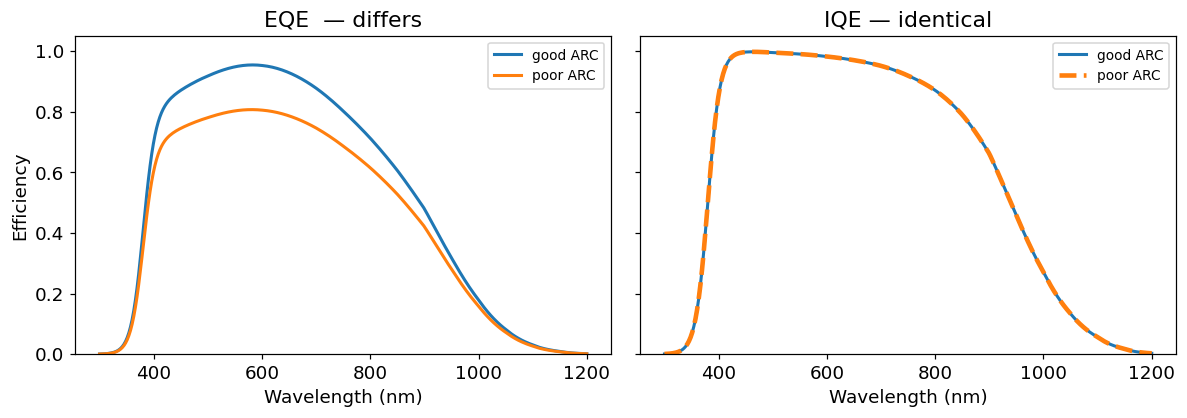

In [7]:
wl = np.linspace(300, 1200, 300)

# Same cell, two different anti-reflection coatings (an OPTICAL change only)
R_good = eh.arc_reflectance(wl)                              # good ARC
R_poor = eh.arc_reflectance(wl, R_min=0.18, R_uv=0.42)       # poor ARC

eqe_good = eh.eqe_spectrum(wl, L_um=250, S_cm_s=100, reflectance=R_good)
eqe_poor = eh.eqe_spectrum(wl, L_um=250, S_cm_s=100, reflectance=R_poor)

iqe_good = eh.iqe_from_eqe(eqe_good, R_good)     # Eq. (10)
iqe_poor = eh.iqe_from_eqe(eqe_poor, R_poor)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

axes[0].plot(wl, eqe_good, lw=2, label='good ARC')
axes[0].plot(wl, eqe_poor, lw=2, label='poor ARC')
axes[0].set_title('EQE  — differs'); axes[0].set_ylabel('Efficiency')

axes[1].plot(wl, iqe_good, lw=2, label='good ARC')
axes[1].plot(wl, iqe_poor, lw=3, ls='--', label='poor ARC')
axes[1].set_title('IQE — identical')

for ax in axes:
    ax.set_xlabel('Wavelength (nm)'); ax.set_ylim(0, 1.05); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"Jsc, good ARC : {eh.jsc_from_eqe(wl, eqe_good):.2f} mA/cm^2")
print(f"Jsc, poor ARC : {eh.jsc_from_eqe(wl, eqe_poor):.2f} mA/cm^2")
print("IQE curves agree:",
      np.allclose(iqe_good[wl > 350], iqe_poor[wl > 350], equal_nan=True))

This is the whole point of IQE. Two cells, electrically identical,
differing only in their coating: their **EQE curves differ and their
$J_{sc}$ differs**, but their **IQE curves lie exactly on top of each
other**. So:

- EQE dropped **and** IQE dropped $\rightarrow$ an **electrical** problem
  (lifetime, passivation, junction).
- EQE dropped but IQE unchanged $\rightarrow$ an **optical** problem
  (coating, texture, shading).

EQE tells you *how much current you get*; IQE tells you *why*.

## 7. Spectral response

EQE is defined per *photon*, but an instrument measures **current** for a
given **optical power**. That ratio is the **spectral response** $SR$
(also called spectral responsivity), in amps per watt:

$$
SR(\lambda) = \text{EQE}(\lambda)\,\frac{q\lambda}{hc} \tag{12}
$$

$$
\text{EQE}(\lambda) = SR(\lambda)\,\frac{hc}{q\lambda} \tag{13}
$$

The two carry the same information; (13) is just (12) rearranged. The
factor $\lambda$ comes straight from (1): one watt of red light contains
more photons than one watt of blue light, so the same EQE yields more
current per watt at longer wavelength. This is why $SR$ keeps rising
across the plateau where EQE is flat, and why **$SR$ — not EQE — is the
quantity a measurement actually produces** (Section 10).

Round trip SR -> EQE exact: True


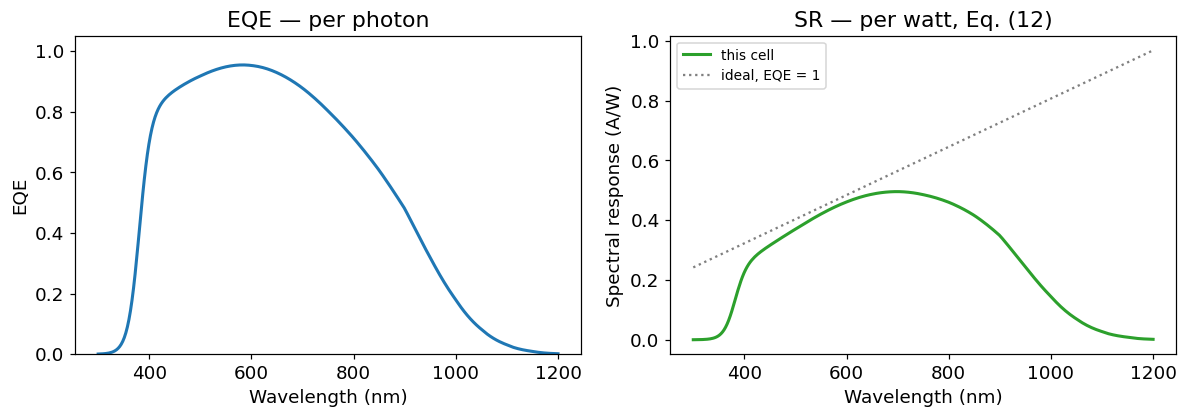

In [8]:
wl = np.linspace(300, 1200, 300)
eqe = eh.eqe_spectrum(wl, L_um=250, S_cm_s=100)

SR = eh.spectral_response_from_eqe(wl, eqe)      # Eq. (12), A/W

# The ideal limit: EQE = 1 at every wavelength
SR_ideal = eh.spectral_response_from_eqe(wl, np.ones_like(wl))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(wl, eqe, lw=2, color='C0')
axes[0].set_ylabel('EQE'); axes[0].set_ylim(0, 1.05)
axes[0].set_title('EQE — per photon')

axes[1].plot(wl, SR, lw=2, color='C2', label='this cell')
axes[1].plot(wl, SR_ideal, ls=':', color='gray', label='ideal, EQE = 1')
axes[1].set_ylabel('Spectral response (A/W)')
axes[1].set_title('SR — per watt, Eq. (12)')
axes[1].legend(fontsize=9)

for ax in axes:
    ax.set_xlabel('Wavelength (nm)')
plt.tight_layout(); plt.show()

# Eq. (13) recovers EQE exactly
print("Round trip SR -> EQE exact:",
      np.allclose(eh.eqe_from_spectral_response(wl, SR), eqe))

The dotted line is the physical ceiling: a perfect cell converting
every photon still has an $SR$ that rises linearly with $\lambda$, purely
because of (1). Comparing a measured $SR$ against that ceiling is another
way of reading EQE.

## 8. Short-circuit current from EQE

EQE also predicts a headline device parameter. Each wavelength
contributes photons at a rate $\Phi_0(\lambda)$ (the spectral photon flux
of the illumination), of which a fraction EQE becomes collected charge:

$$
J_{sc} = q \int \Phi_0(\lambda)\,\text{EQE}(\lambda)\, d\lambda \tag{14}
$$

Under standard test conditions, $\Phi_0$ is the AM1.5G reference
spectrum. Equation (14) is what makes EQE quantitative rather than merely
diagnostic — and it is also the basis of the calibration in Section 11.

Jsc over 300-1200 nm = 27.43 mA/cm^2


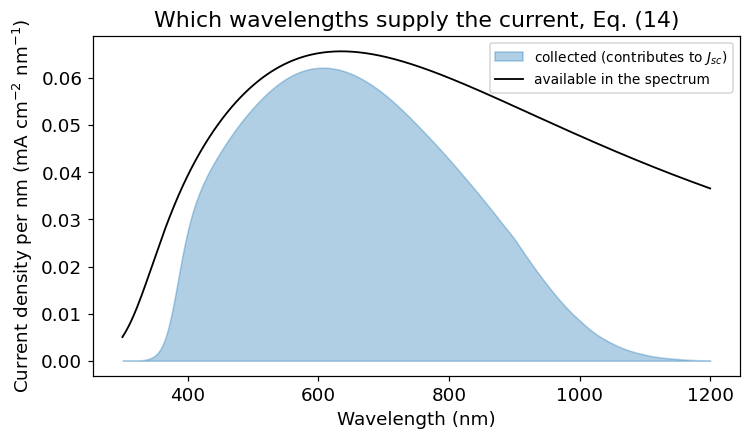

In [9]:
wl = np.linspace(300, 1200, 400)
eqe = eh.eqe_spectrum(wl, L_um=250, S_cm_s=100)

spectrum = eh.am15g_simplified(wl)                       # W/(m^2 nm)
phi0 = eh.photon_flux_spectral(wl, spectrum)             # photons/(s m^2 nm)
contribution = eh.Q * phi0 * eqe * 1e-1                  # mA/cm^2 per nm

fig, ax1 = plt.subplots(figsize=(7, 4.2))
ax1.fill_between(wl, contribution, alpha=0.35, color='C0',
                 label='collected (contributes to $J_{sc}$)')
ax1.plot(wl, eh.Q * phi0 * 1e-1, color='k', lw=1.2,
         label='available in the spectrum')
ax1.set_xlabel('Wavelength (nm)')
ax1.set_ylabel('Current density per nm (mA cm$^{-2}$ nm$^{-1}$)')
ax1.legend(fontsize=9)
plt.title('Which wavelengths supply the current, Eq. (14)')
plt.tight_layout(); plt.show()

jsc = eh.jsc_from_eqe(wl, eqe)                           # Eq. (14)
print(f"Jsc over 300-1200 nm = {jsc:.2f} mA/cm^2")

The gap between the two curves is the loss budget, resolved by
wavelength — the area you would recover by fixing each loss mechanism.

## 9. Reading a real device: front vs rear

Because wavelength selects depth (Section 2), the two ends of the curve
interrogate opposite faces of the cell:

| Region | Probes | Sensitive to |
|---|---|---|
| 300-500 nm | front surface, emitter | coating, front passivation, emitter doping |
| 500-900 nm | base (bulk) | overall optics, bulk quality |
| 900-1200 nm | deep base, rear surface | diffusion length $L$, rear velocity $S$, rear reflector |

A standard illustration is the aluminium back-surface-field (Al-BSF) cell
versus the passivated emitter and rear cell (PERC). PERC adds a
dielectric rear layer that both passivates the rear (lower $S$) and
reflects weakly absorbed light back into the cell. The difference should
appear **only in the near-IR**.

<div align="center">
   <img src="./figures/fig_albsf_vs_perc.jpg" width="640">
</div>

Jsc Al-BSF-like : 26.37 mA/cm^2
Jsc PERC-like   : 28.37 mA/cm^2


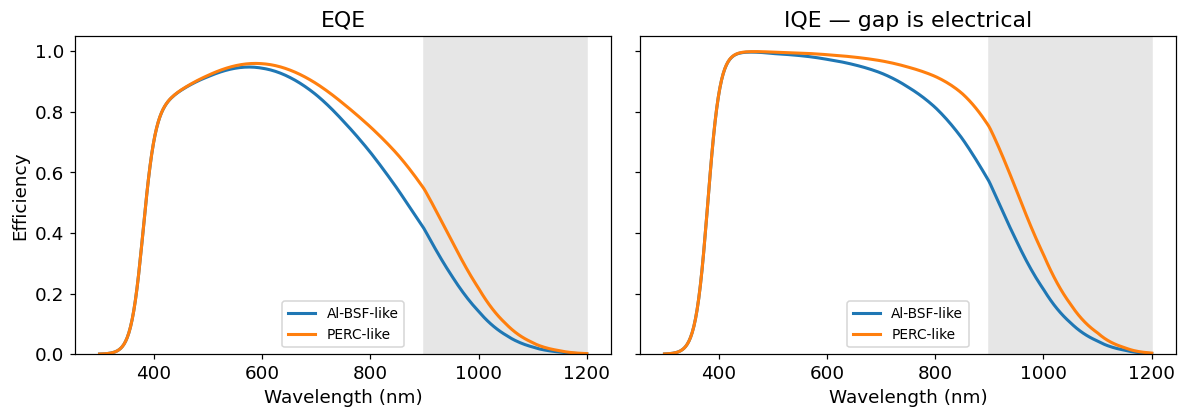

In [10]:
wl = np.linspace(300, 1200, 300)

# Al-BSF-like: shorter diffusion length, fast rear recombination
eqe_albsf = eh.eqe_spectrum(wl, W_um=160, L_um=150, S_cm_s=1000.0)
# PERC-like: longer diffusion length, well-passivated rear
eqe_perc = eh.eqe_spectrum(wl, W_um=160, L_um=250, S_cm_s=20.0)

R = eh.arc_reflectance(wl)                    # identical front optics
iqe_albsf = eh.iqe_from_eqe(eqe_albsf, R)     # Eq. (10)
iqe_perc = eh.iqe_from_eqe(eqe_perc, R)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

axes[0].plot(wl, eqe_albsf, lw=2, label='Al-BSF-like')
axes[0].plot(wl, eqe_perc, lw=2, label='PERC-like')
axes[0].set_title('EQE'); axes[0].set_ylabel('Efficiency')

axes[1].plot(wl, iqe_albsf, lw=2, label='Al-BSF-like')
axes[1].plot(wl, iqe_perc, lw=2, label='PERC-like')
axes[1].set_title('IQE — gap is electrical')

for ax in axes:
    ax.axvspan(900, 1200, color='0.9', zorder=0)
    ax.set_xlabel('Wavelength (nm)'); ax.set_ylim(0, 1.05); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"Jsc Al-BSF-like : {eh.jsc_from_eqe(wl, eqe_albsf):.2f} mA/cm^2")
print(f"Jsc PERC-like   : {eh.jsc_from_eqe(wl, eqe_perc):.2f} mA/cm^2")

The curves are indistinguishable below about 700 nm and separate
progressively across the shaded near-IR band — exactly the signature of a
rear-side difference.
Because both cells here share the same front optics, IQE separates by the
same amount as EQE, confirming the cause is electrical rather than
optical.

## 10. Measuring: spectral response and the DSR method

EQE cannot be measured directly. What an instrument measures is current
per unit optical power, i.e. $SR$ from Section 7, which is then converted
to EQE with (13).

One further complication: a solar cell's response can depend on how
strongly it is already illuminated, because recombination is
injection-dependent. Measuring a dark cell with a dim monochromatic beam
would not describe the cell at operating conditions. The standard
solution is a **differential** measurement:

1. Hold the cell under steady white **bias light**, setting a realistic
   injection level.
2. Add a small, chopped **monochromatic** beam of wavelength $\lambda$.
3. Recover the resulting small AC current with a lock-in amplifier.

The measured quantity is the **differential spectral responsivity**:

$$
\tilde{s}(\lambda, E_{\text{bias}})
= \frac{\Delta j_{sc}(\lambda)}{\Delta E_\lambda(\lambda)} \tag{15}
$$

<div align="center">
   <img src="./figures/fig_measurement_setup.jpg" width="660">
</div>

The absolute scale of $\Delta E_\lambda$ is not known from the instrument
alone, so a **reference cell** of known responsivity is measured under
the same conditions and the unknown gain factors divide out — but only up
to one constant, which Section 11 fixes.

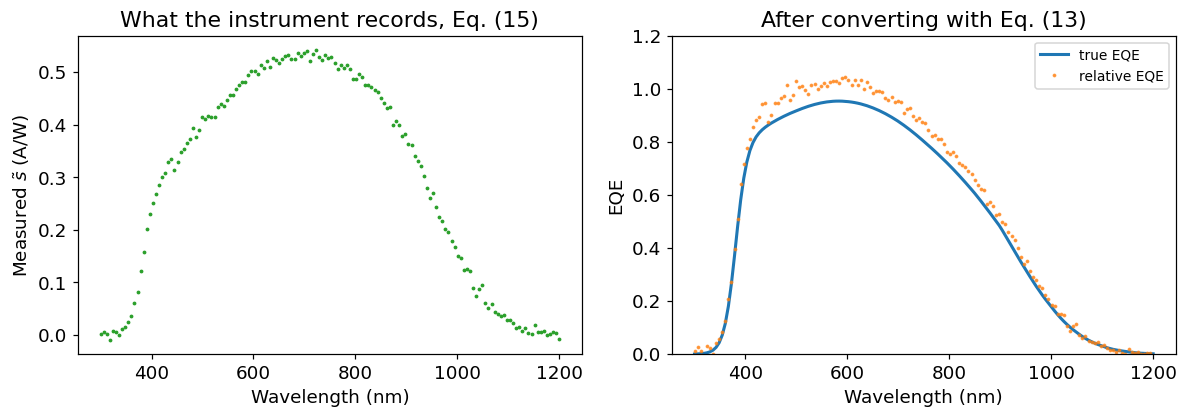

In [11]:
wl = np.linspace(300, 1200, 150)
eqe_true = eh.eqe_spectrum(wl, W_um=160, L_um=250, S_cm_s=100.0)

# A realistic measurement: noise, plus an unknown overall calibration
# scale factor left over from the reference-cell comparison, Eq. (15)
s_measured = eh.synthetic_dsr_measurement(
    wl, eqe_true, noise_level=0.015, calibration_scale=1.08, random_state=1)

eqe_relative = eh.eqe_from_spectral_response(wl, s_measured)   # Eq. (13)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(wl, s_measured, '.', ms=3, color='C2')
axes[0].set_ylabel('Measured $\\tilde{s}$ (A/W)')
axes[0].set_title('What the instrument records, Eq. (15)')

axes[1].plot(wl, eqe_true, lw=2, label='true EQE')
axes[1].plot(wl, eqe_relative, '.', ms=3, alpha=0.7, label='relative EQE')
axes[1].set_ylabel('EQE'); axes[1].set_ylim(0, 1.2)
axes[1].set_title('After converting with Eq. (13)')
axes[1].legend(fontsize=9)

for ax in axes:
    ax.set_xlabel('Wavelength (nm)')
plt.tight_layout(); plt.show()

## 11. From relative to absolute EQE

The converted curve has the right *shape* but the wrong *scale* — note
that it exceeds 1, which is unphysical. The remaining unknown constant is
removed by requiring that the EQE reproduce an independently measured
short-circuit current, via (14):

$$
f_{sc} = \frac{J_{sc,\text{exp}}}{J_{sc,\text{calc}}},
\qquad
\text{EQE}_{\text{abs}}(\lambda) = f_{sc}\cdot \text{EQE}_{\text{rel}}(\lambda) \tag{16}
$$

where $J_{sc,\text{exp}}$ comes from a solar simulator measurement and
$J_{sc,\text{calc}}$ from integrating the relative EQE against the
reference spectrum. A well-calibrated setup gives $f_{sc}$ close to 1 —
the synthetic data below carries a deliberate 8% miscalibration, which
(16) removes. A value far from 1 signals a measurement problem rather
than a property of the cell.

Jsc measured   = 27.43 mA/cm^2
Jsc calculated = 29.57 mA/cm^2
scaling factor = 0.928


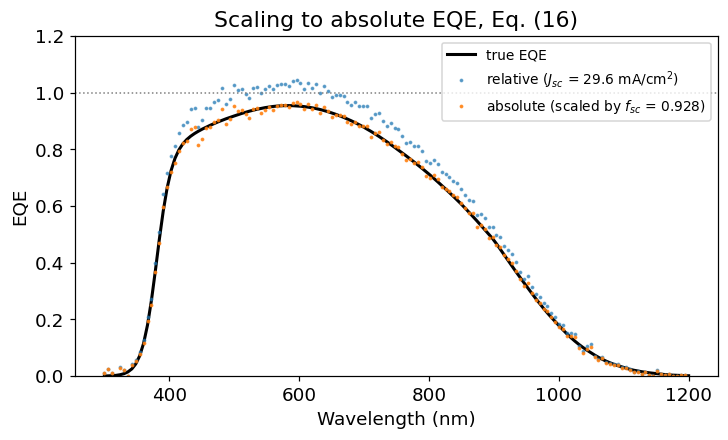

In [12]:
jsc_calc = eh.jsc_from_eqe(wl, eqe_relative)      # Eq. (14)

# Independent solar-simulator measurement of the same cell
jsc_exp = eh.jsc_from_eqe(wl, eqe_true)

f_sc = jsc_exp / jsc_calc                          # Eq. (16)
eqe_absolute = f_sc * eqe_relative

plt.figure(figsize=(6.8, 4.2))
plt.plot(wl, eqe_true, lw=2, color='k', label='true EQE')
plt.plot(wl, eqe_relative, '.', ms=3, alpha=0.6,
         label=f'relative ($J_{{sc}}$ = {jsc_calc:.1f} mA/cm$^2$)')
plt.plot(wl, eqe_absolute, '.', ms=3, alpha=0.8,
         label=f'absolute (scaled by $f_{{sc}}$ = {f_sc:.3f})')
plt.axhline(1.0, ls=':', color='gray', lw=1)
plt.xlabel('Wavelength (nm)'); plt.ylabel('EQE'); plt.ylim(0, 1.2)
plt.legend(fontsize=9); plt.title('Scaling to absolute EQE, Eq. (16)')
plt.tight_layout(); plt.show()

print(f"Jsc measured   = {jsc_exp:.2f} mA/cm^2")
print(f"Jsc calculated = {jsc_calc:.2f} mA/cm^2")
print(f"scaling factor = {f_sc:.3f}")

## 12. Linearity and bias-ramp measurements

If a cell is perfectly **linear**, its differential response $\tilde{s}$
does not depend on the bias level, and a single measurement suffices.
Real cells can deviate. The rigorous definition integrates $\tilde{s}$
over bias irradiance up to one sun:

$$
s_{\text{STC}}(\lambda) = \int_0^{1000\ \text{W/m}^2}
\tilde{s}(\lambda, E_{\text{bias}})\; dE_{\text{bias}} \tag{17}
$$

Measuring that full integral at every wavelength is slow, so simplified
procedures use a single bias point (commonly around
$300\ \text{W/m}^2$), which approximates (17) well for typical silicon
cells. A **bias ramp** — sweeping $E_{\text{bias}}$ at a fixed wavelength
— is how you check whether that shortcut is valid for a given device.

Nonlinear cell: measuring at 300 W/m^2 instead of 1000 W/m^2 misestimates SR by -4.3%


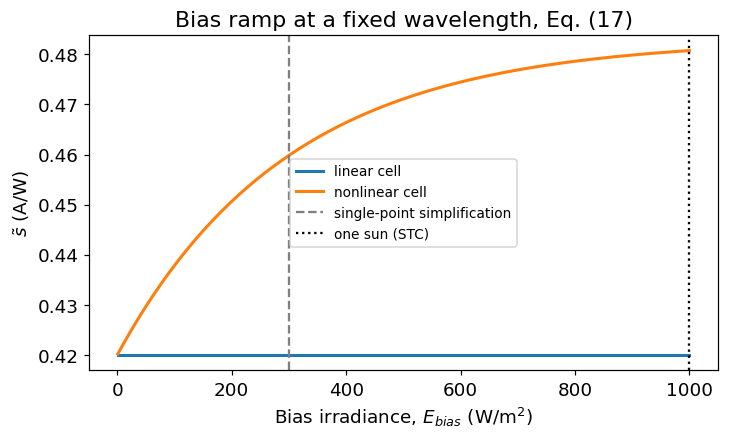

In [13]:
E_bias = np.linspace(1, 1000, 200)     # W/m^2
s_stc = 0.42                            # A/W at the chosen wavelength

s_linear = eh.bias_ramp_dsr(E_bias, s_stc, nonlinearity=0.0)
s_nonlin = eh.bias_ramp_dsr(E_bias, s_stc, nonlinearity=0.15)

plt.figure(figsize=(6.8, 4.2))
plt.plot(E_bias, s_linear, lw=2, label='linear cell')
plt.plot(E_bias, s_nonlin, lw=2, label='nonlinear cell')
plt.axvline(300, ls='--', color='gray', label='single-point simplification')
plt.axvline(1000, ls=':', color='k', label='one sun (STC)')
plt.xlabel(r'Bias irradiance, $E_{bias}$ (W/m$^2$)')
plt.ylabel(r'$\tilde{s}$ (A/W)')
plt.legend(fontsize=9); plt.title('Bias ramp at a fixed wavelength, Eq. (17)')
plt.tight_layout(); plt.show()

dev = 100 * (s_nonlin[np.argmin(abs(E_bias - 300))] / s_nonlin[-1] - 1)
print(f"Nonlinear cell: measuring at 300 W/m^2 instead of 1000 W/m^2 "
      f"misestimates SR by {dev:+.1f}%")

A flat line means the shortcut is safe. A sloping line means the
single-point measurement carries a systematic error, which must either be
corrected or reported.

## 13. Assumptions and limitations

The models here are deliberately simple. They assume:

- **one-dimensional** transport — no lateral current flow or finger
  shading effects;
- **uniform material** — constant $D$, $L$ and doping with depth, so the
  emitter is represented only by an empirical front-loss term;
- an **analytic reflectance** shape, not a thin-film interference
  calculation, and no explicit light-trapping / multiple-pass optics;
- a **coarse $\alpha(\lambda)$** interpolation and an approximate AM1.5G
  spectrum, adequate for shapes and trends but not for certification;
- **no series resistance** or injection-dependent recombination beyond
  the illustrative bias-ramp model of (17).

They are sufficient to explain and interpret the shape of an EQE curve,
which is the purpose here. Quantitative device work needs tabulated
optical constants, the standard reference spectrum, and a numerical
device simulator.

## Summary of equations

| # | Equation | Meaning |
|---|---|---|
| (1) | $E_{\text{phot}} = hc/\lambda$ | photon energy |
| (2) | $\Phi = \Phi_0 e^{-\alpha z}$ | Lambert-Beer absorption |
| (3) | $L_\alpha = 1/\alpha$ | absorption length |
| (4) | $T_{\text{ext}} = 1 - R - A_{\text{ext}}$ | light that reaches the absorber |
| (5) | $g = (1-R)\Phi_0\alpha e^{-\alpha z}$ | generation rate |
| (6) | $L = \sqrt{D\tau}$ | diffusion length |
| (7) | $\eta_c = \cosh(z/L) - (L/L_{\text{eff}})\sinh(z/L)$ | collection efficiency |
| (8) | $L_{\text{eff}} = L\,\frac{S\sinh + D\cosh}{S\cosh + D\sinh}$ | effective diffusion length |
| (9) | $\text{EQE} = \frac{1}{\Phi_0}\int_0^W g\,\eta_c\,dz$ | external quantum efficiency |
| (10) | $\text{IQE} = \text{EQE}/(1-R)$ | internal quantum efficiency |
| (11) | $\text{EQE} = T_{\text{ext}}\cdot\text{IQE}$ | optics × electronics |
| (12) | $SR = \text{EQE}\;q\lambda/hc$ | spectral response |
| (13) | $\text{EQE} = SR\;hc/q\lambda$ | conversion back to EQE |
| (14) | $J_{sc} = q\int \Phi_0\,\text{EQE}\,d\lambda$ | short-circuit current |
| (15) | $\tilde{s} = \Delta j_{sc}/\Delta E_\lambda$ | differential spectral responsivity |
| (16) | $f_{sc} = J_{sc,\text{exp}}/J_{sc,\text{calc}}$ | absolute scaling factor |
| (17) | $s_{\text{STC}} = \int_0^{1000} \tilde{s}\,dE_{\text{bias}}$ | responsivity at STC |